# PyTorch 이진분류 개선 실습: 유방암 진단 (ver.1)

**목적:** 기존 모델(Accuracy 0.91)의 구조적 결함을 진단하고, 단계별 개선을 통해 성능과 임상 신뢰성을 높인다.

**문제 유형:** 지도학습 — 이진 분류 (Supervised Learning · Binary Classification)

<br>

---

## 기존 모델의 구조적 결함 진단

| # | 결함 | 근거 | 영향 |
|---|------|------|------|
| 1 | **StandardScaler 미적용** | `area` 범위(143 ~ 2501) vs `fractal_dimension`(0.05 ~ 0.1) — 수백 배 차이 | Adam 기울기가 스케일이 큰 피처에 지배됨 |
| 2 | **Sigmoid + BCELoss 조합** | Sigmoid 출력값이 0/1 근방에서 수치 불안정 | `BCEWithLogitsLoss`가 log-sum-exp trick으로 안정적 |
| 3 | **클래스 불균형 미처리** | Malignant 212 vs Benign 357 (1 : 1.68) | 모델이 Benign(다수 클래스) 예측 편향 |
| 4 | **평가 지표 빈약** | `accuracy`만 사용 | 악성→양성 오진(FN)이 위험한 의료 맥락에서 **Recall**이 핵심 |
| 5 | **임계값 0.5 고정** | `.round()` = threshold 0.5 | Recall 최대화를 위해 임계값 조정이 필요 |

<br>

---

## 개선 파이프라인

```
[0] 공통 설정 (시드, 디바이스)
      ↓
[1] 데이터 로드 및 EDA
      ↓
[2] 데이터 분할 + StandardScaler (개선 1)
      ↓
[3] Dataset / DataLoader
      ↓
[4] 모델 정의: BatchNorm + Dropout (개선 2)
      ↓
[5] BCEWithLogitsLoss + pos_weight (개선 3, 4)
      ↓
[6] 학습 루프 + Early Stopping
      ↓
[7] 평가: Confusion Matrix · AUC · Classification Report (개선 5)
      ↓
[8] 임계값 최적화 (개선 6)
      ↓
[9] 기존 모델과 최종 비교
```

---
## 0. 공통 설정

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)


def set_seed(seed: int = 42) -> None:
    """재현성 보장: 모든 난수 생성기 시드 고정."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

[Device] cuda


---
## 1. 데이터 로드 및 EDA

### 데이터셋 명세

| 항목 | 내용 |
|------|------|
| 출처 | `sklearn.datasets.load_breast_cancer` (Wisconsin Diagnostic, 1995) |
| 샘플 수 | 569명 |
| 독립변수 | 30개 수치형 (평균·표준오차·최악값 × 10종 형태학적 지표) |
| 종속변수 | 0=Malignant(악성, 212명) / 1=Benign(양성, 357명) |
| **클래스 비율** | **Malignant : Benign = 37.3% : 62.7%** |



---
<br>

**주의 — 레이블 인코딩 방향:**
sklearn의 Breast Cancer 데이터는 `0=Malignant, 1=Benign`으로 인코딩되어 있다.
즉 Positive(1) = Benign, Negative(0) = Malignant이다.
F1/Recall의 기본값은 Positive(1=Benign) 기준으로 계산된다.
임상적으로 중요한 것은 Malignant(0)를 놓치지 않는 것이므로,
**✳️Malignant Recall = Negative Recall = Specificity✳️**가 핵심 지표가 된다.

In [2]:
dataset = load_breast_cancer()
x, y = dataset.data, dataset.target
feat_names = dataset.feature_names

print("[데이터셋 기초 정보]")
print(f"  Shape: X={x.shape}, y={y.shape}")
print(f"  클래스 분포: Malignant(0)={np.sum(y==0)}, Benign(1)={np.sum(y==1)}")
print(f"  Malignant 비율: {np.mean(y==0)*100:.1f}%")
print()

# 피처 스케일 확인 — StandardScaler 필요성 진단
print("[개선 근거 1] 피처 스케일 불균형 확인")
print(f"  {'피처':<35} {'Min':>8} {'Max':>10} {'비율(Max/Min)':>14}")
print(f"  {'-'*68}")
for i, name in enumerate(feat_names):
    mn, mx = x[:, i].min(), x[:, i].max()
    ratio = mx / mn if mn > 0 else float('inf')
    if ratio > 100 or i in [0, 2, 3, 9, 13]:  # 극단적 스케일 피처만 출력
        print(f"  {name:<35} {mn:>8.3f} {mx:>10.3f} {ratio:>14.1f}x")
print("  → area(143~2501)와 fractal_dimension(0.05~0.1)의 스케일 차이가 수천 배")
print("  → StandardScaler 적용 필수")

print()
# pos_weight 계산
n_neg = np.sum(y == 0)  # Malignant
n_pos = np.sum(y == 1)  # Benign
pos_weight_value = n_neg / n_pos  # BCEWithLogitsLoss pos_weight 공식
print(f"[개선 근거 3] pos_weight = n_neg/n_pos = {n_neg}/{n_pos} = {pos_weight_value:.4f}")
print(f"  → Malignant(소수 클래스)의 오분류 패널티를 높여 불균형 보정")

[데이터셋 기초 정보]
  Shape: X=(569, 30), y=(569,)
  클래스 분포: Malignant(0)=212, Benign(1)=357
  Malignant 비율: 37.3%

[개선 근거 1] 피처 스케일 불균형 확인
  피처                                       Min        Max    비율(Max/Min)
  --------------------------------------------------------------------
  mean radius                            6.981     28.110            4.0x
  mean perimeter                        43.790    188.500            4.3x
  mean area                            143.500   2501.000           17.4x
  mean concavity                         0.000      0.427            infx
  mean concave points                    0.000      0.201            infx
  mean fractal dimension                 0.050      0.097            2.0x
  area error                             6.802    542.200           79.7x
  concavity error                        0.000      0.396            infx
  concave points error                   0.000      0.053            infx
  worst concavity                        0.000      1.252

---
## 2. 데이터 분할 + StandardScaler

### 개선 1: StandardScaler 적용

**적용 원칙 — Data Leakage 방지:**
- `scaler.fit()`은 반드시 **Train 세트에만** 호출한다.
- Val·Test 세트에는 `scaler.transform()`만 적용한다.
- Val/Test의 통계량이 scaler에 반영되면 미래 데이터를 학습 시 참조한 셈이 된다.

**BCEWithLogitsLoss 사용 시 y shape:**
- 출력 텐서: `(N, 1)` → loss 계산을 위해 y도 `(N, 1)` 또는 flatten으로 맞춰야 한다.
- 여기서는 y를 `(N,)` 유지하고 forward에서 `.flatten()`으로 처리한다.

In [3]:
# ── 데이터 분할 ───────────────────────────────────────────────────────────────
x_tv, x_test, y_tv, y_test = train_test_split(
    x, y, test_size=0.2, random_state=SEED, stratify=y
    # stratify=y: 클래스 비율을 각 분할에서 동일하게 유지
)
x_train, x_val, y_train, y_val = train_test_split(
    x_tv, y_tv, test_size=0.2, random_state=SEED, stratify=y_tv
)

print("[데이터 분할]")
for name, xarr, yarr in [("Train", x_train, y_train),
                          ("Val",   x_val,   y_val),
                          ("Test",  x_test,  y_test)]:
    mal = np.sum(yarr==0)
    ben = np.sum(yarr==1)
    print(f"  {name:5s}: {len(xarr):3d}개  "
          f"Malignant={mal}({mal/len(yarr)*100:.1f}%)  "
          f"Benign={ben}({ben/len(yarr)*100:.1f}%)")

# ── StandardScaler 적용 (개선 1) ──────────────────────────────────────────────
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)   # fit + transform: Train만
x_val_sc   = scaler.transform(x_val)          # transform only: Val
x_test_sc  = scaler.transform(x_test)         # transform only: Test

print()
print("[StandardScaler 적용 후 Train 피처 통계]")
print(f"  Mean 범위: [{x_train_sc.mean(axis=0).min():.4f}, "
      f"{x_train_sc.mean(axis=0).max():.4f}]  (≈ 0이어야 함)")
print(f"  Std  범위: [{x_train_sc.std(axis=0).min():.4f}, "
      f"{x_train_sc.std(axis=0).max():.4f}]   (≈ 1이어야 함)")

[데이터 분할]
  Train: 364개  Malignant=136(37.4%)  Benign=228(62.6%)
  Val  :  91개  Malignant=34(37.4%)  Benign=57(62.6%)
  Test : 114개  Malignant=42(36.8%)  Benign=72(63.2%)

[StandardScaler 적용 후 Train 피처 통계]
  Mean 범위: [-0.0000, 0.0000]  (≈ 0이어야 함)
  Std  범위: [1.0000, 1.0000]   (≈ 1이어야 함)


---
## 3. Dataset / DataLoader

In [4]:
def build_loader(x_arr, y_arr, batch_size=32, shuffle=True):
    """
    NumPy 배열을 float32 Tensor로 변환 후 DataLoader를 반환한다.

    y dtype: float32 — BCEWithLogitsLoss는 float 입력을 요구한다.
    batch_size=32: 배치 크기를 기존(64)에서 줄인 이유 →
      n_train≈365에서 배치 64이면 1 에포크 = 6배치로 너무 적다.
      32로 줄이면 약 11배치로 기울기 추정의 다양성이 증가한다.
    """
    xt = torch.tensor(x_arr, dtype=torch.float32)
    yt = torch.tensor(y_arr, dtype=torch.float32)
    return DataLoader(TensorDataset(xt, yt),
                      batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE = 32
train_loader = build_loader(x_train_sc, y_train, BATCH_SIZE, shuffle=True)
val_loader   = build_loader(x_val_sc,   y_val,   BATCH_SIZE, shuffle=False)

# Test Tensor (DataLoader 불필요 — 한 번만 평가)
x_test_t = torch.tensor(x_test_sc, dtype=torch.float32)
y_test_t = torch.tensor(y_test,    dtype=torch.float32)

print(f"[DataLoader]  Train: {len(train_loader)}배치  Val: {len(val_loader)}배치  "
      f"(batch_size={BATCH_SIZE})")

[DataLoader]  Train: 12배치  Val: 3배치  (batch_size=32)


---
## 4. 모델 정의

### 개선 2: BatchNorm + Dropout

**아키텍처 비교:**

```
[기존]
Linear(30→64) → ReLU → Linear(64→32) → ReLU → Linear(32→32) → ReLU → Linear(32→1) → Sigmoid

[개선]
Linear(30→64) → BN(64) → ReLU → Dropout(0.3)
→ Linear(64→32) → BN(32) → ReLU → Dropout(0.3)
→ Linear(32→1)  [Sigmoid 제거 — BCEWithLogitsLoss가 내부 처리]
```

**설계 결정:**
- `Linear(32→32)` 동일 차원 층 제거: 표현력 기여 없이 파라미터만 추가하는 구조
- `Sigmoid` 출력층 제거: `BCEWithLogitsLoss`는 내부적으로 sigmoid를 포함하며
  log-sum-exp trick으로 수치 안정성을 보장한다
- `BatchNorm1d` 위치: `Linear → BN → ReLU` 순서 (원논문 권장)
- `Dropout(p=0.3)`: ReLU 이후 적용. n=365(train)의 소규모 데이터에서
  p=0.5는 과도하다. p=0.2~0.3이 적절한 출발점.

In [5]:
class BinaryClassifierImproved(nn.Module):
    """
    개선된 이진분류 MLP.

    구조: Linear → BN → ReLU → Dropout (×2) → Linear(출력)
    출력: 로짓(logit) — Sigmoid를 적용하지 않는다.
          BCEWithLogitsLoss 또는 추론 시 Sigmoid를 직접 적용한다.

    Args:
        input_dim : 입력 피처 수 (기본: 30)
        dropout_p : Dropout 비율 (기본: 0.3)
    """
    def __init__(self, input_dim: int = 30, dropout_p: float = 0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),          # 입력 분포 정규화
            nn.ReLU(),
            nn.Dropout(p=dropout_p),     # 과적합 억제

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(32, 1),            # 출력: 로짓 (Sigmoid 없음)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)           # shape: (batch, 1)


set_seed(SEED)
model = BinaryClassifierImproved(input_dim=x_train_sc.shape[1]).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("[모델 구조]")
print(model)
print(f"\n총 학습 가능 파라미터: {total_params:,}")

[모델 구조]
BinaryClassifierImproved(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

총 학습 가능 파라미터: 4,289


---
## 5. 손실 함수 및 옵티마이저

### 개선 3: BCEWithLogitsLoss (Sigmoid 수치 안정성)

$$\mathcal{L} = -\frac{1}{N}\sum\left[ y \log\sigma(\hat{y}) + (1-y)\log(1-\sigma(\hat{y})) \right]$$

`BCEWithLogitsLoss`는 위 식을 `log(1 + exp(-x))`(numerically stable) 형태로 계산한다.
기존 `Sigmoid → BCELoss`는 sigmoid 출력이 0 또는 1에 가까울 때 `log(0)` → `inf`가 발생할 수 있다.

<br>


### 개선 4: pos_weight로 클래스 불균형 보정

$$\text{pos\_weight} = \frac{n_{\text{negative}}}{n_{\text{positive}}} = \frac{212}{357} \approx 0.594$$

- `pos_weight < 1`: Positive(Benign)의 오분류 패널티를 낮추고
  Negative(Malignant)의 오분류 패널티를 상대적으로 높인다.
- 이 값은 Malignant를 Benign으로 잘못 분류하는 비용을 증가시킨다.

**한계:** `pos_weight`는 학습 손실에만 영향을 준다.
임계값 0.5는 여전히 고정이므로 섹션 8에서 별도로 최적화한다.

In [6]:
# ── pos_weight 계산 (Train 세트 기준) ─────────────────────────────────────────
n_neg_train = np.sum(y_train == 0)  # Malignant
n_pos_train = np.sum(y_train == 1)  # Benign
pos_weight   = torch.tensor([n_neg_train / n_pos_train], dtype=torch.float32).to(device)

print(f"[pos_weight] {n_neg_train}/{n_pos_train} = {pos_weight.item():.4f}")

# ── 손실 함수 (개선 3, 4) ─────────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── 옵티마이저 ────────────────────────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
# weight_decay=1e-4: L2 정규화 추가. Dropout과 함께 이중 정규화.

print(f"[손실 함수] BCEWithLogitsLoss (pos_weight={pos_weight.item():.4f})")
print(f"[옵티마이저] Adam (lr=0.001, weight_decay=1e-4)")

[pos_weight] 136/228 = 0.5965
[손실 함수] BCEWithLogitsLoss (pos_weight=0.5965)
[옵티마이저] Adam (lr=0.001, weight_decay=1e-4)


---
## 6. 학습 루프 + Early Stopping

**이진분류 학습 루프의 회귀와의 차이점:**
- 예측값이 로짓(logit)이므로 정확도 계산 시 `sigmoid → round → 비교` 과정이 필요
- `torch.sigmoid(logits) > 0.5` = 이진 예측 (threshold=0.5)
- 손실: `BCEWithLogitsLoss(logits, labels)` — sigmoid 적용 불필요

**Early Stopping `patience=30`:**
- 기존(100 에포크 고정)과 달리, Val Loss가 30 에포크 연속 무개선이면 중단한다.
- 최적 가중치는 `best_state`에 저장 후 복원한다.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    """1 에포크 학습. (loss, accuracy) 반환."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb).flatten()       # (batch,1) → (batch,)
        loss   = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds  = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == yb).sum().item()
        total   += len(yb)

    return total_loss / len(loader), correct / total


def evaluate_epoch(model, loader, criterion):
    """검증 손실 및 정확도 계산. 가중치 갱신 없음."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).flatten()
            loss   = criterion(logits, yb)

            total_loss += loss.item()
            preds  = (torch.sigmoid(logits) >= 0.5).float()
            correct += (preds == yb).sum().item()
            total   += len(yb)

    return total_loss / len(loader), correct / total


print("[유틸리티 로드 완료]")

[유틸리티 로드 완료]


In [8]:
NUM_EPOCHS = 300
PATIENCE   = 30

train_losses, val_losses  = [], []
train_accs,   val_accs    = [], []
best_val_loss  = float("inf")
no_improve     = 0
best_state     = None
best_epoch     = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate_epoch(model, val_loader,   criterion)

    train_losses.append(t_loss); val_losses.append(v_loss)
    train_accs.append(t_acc);   val_accs.append(v_acc)

    # ── Early Stopping ────────────────────────────────────────────────────────
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_epoch    = epoch
        no_improve    = 0
        best_state    = {k: w.cpu().clone() for k, w in model.state_dict().items()}
    else:
        no_improve += 1

    if epoch % 30 == 0 or epoch == 1:
        print(f"  Epoch {epoch:4d}/{NUM_EPOCHS} | "
              f"Train loss={t_loss:.4f} acc={t_acc:.4f} | "
              f"Val loss={v_loss:.4f} acc={v_acc:.4f}")

    if no_improve >= PATIENCE:
        print(f"\n  [Early Stop] Epoch {epoch} — "
              f"Val Loss 무개선 {PATIENCE}에포크 연속. Best: {best_epoch}")
        break

# 최적 가중치 복원
if best_state:
    model.load_state_dict({k: w.to(device) for k, w in best_state.items()})
print(f"\n  [최적 에포크] {best_epoch} / Val Loss = {best_val_loss:.4f}")

  Epoch    1/300 | Train loss=0.4142 acc=0.6868 | Val loss=0.4173 acc=0.8462
  Epoch   30/300 | Train loss=0.0642 acc=0.9863 | Val loss=0.0641 acc=0.9780
  Epoch   60/300 | Train loss=0.0768 acc=0.9505 | Val loss=0.0494 acc=0.9780
  Epoch   90/300 | Train loss=0.0603 acc=0.9753 | Val loss=0.0475 acc=0.9670

  [Early Stop] Epoch 102 — Val Loss 무개선 30에포크 연속. Best: 72

  [최적 에포크] 72 / Val Loss = 0.0418


---
## 7. 평가: Confusion Matrix · AUC · Classification Report

### 개선 5: 의료 데이터에 적합한 평가 지표

이진분류의 평가 지표 체계:

```
                 예측: Malignant(0)    예측: Benign(1)
실제: Malignant(0)       TN                  FP  ← 악성을 양성으로 오진 (위험!)
실제: Benign(1)          FN                  TP
```

<br>

**임상적 관점에서 중요한 지표:**

| 지표 | 수식 | 임상 의미 |
|------|------|-----------|
| **Malignant Recall (Specificity)** | TN / (TN+FP) | 악성 종양을 올바르게 악성으로 진단한 비율 |
| Benign Recall (Sensitivity) | TP / (TP+FN) | 양성 종양을 올바르게 양성으로 진단한 비율 |
| ROC-AUC | — | threshold 무관 전반적 분류 능력 |

<br>

**주의:** sklearn의 기본 설정은 Positive=1(Benign) 기준이다.
Malignant Recall을 구하려면 `recall_score(..., pos_label=0)`이 필요하다.

In [9]:
def get_predictions(model, x_tensor, threshold=0.5):
    """
    모델 추론: 로짓 → 확률 → 이진 예측.

    Args:
        threshold: 분류 임계값 (기본 0.5)

    Returns:
        (probs, preds): 확률값, 이진 예측값 NumPy 배열
    """
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor.to(device)).flatten().cpu()
        probs  = torch.sigmoid(logits).numpy()
        preds  = (probs >= threshold).astype(int)
    return probs, preds


def print_metrics(y_true, y_pred, probs, label=""):
    """분류 성능 지표를 출력한다."""
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, probs)
    rec_mal = recall_score(y_true, y_pred, pos_label=0)  # Malignant Recall
    rec_ben = recall_score(y_true, y_pred, pos_label=1)  # Benign Recall

    print(f"  [{label}]")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  F1 (Benign)       : {f1:.4f}")
    print(f"  ROC-AUC           : {auc:.4f}")
    print(f"  Recall (Malignant): {rec_mal:.4f}  ← 핵심 — 악성을 놓치지 않는 비율")
    print(f"  Recall (Benign)   : {rec_ben:.4f}")
    return {"acc": acc, "f1": f1, "auc": auc,
            "recall_mal": rec_mal, "recall_ben": rec_ben,
            "probs": probs, "preds": y_pred}


# ── 테스트 세트 평가 (threshold=0.5) ─────────────────────────────────────────
probs_05, preds_05 = get_predictions(model, x_test_t, threshold=0.5)
print("=" * 55)
print("[최종 테스트 성능 — threshold=0.5]")
print("=" * 55)
metrics_05 = print_metrics(y_test, preds_05, probs_05, label="threshold=0.5")

print()
print("[Confusion Matrix (threshold=0.5)]")
cm = confusion_matrix(y_test, preds_05)
print(f"  실제\\예측  Malignant  Benign")
print(f"  Malignant  {cm[0,0]:8d}  {cm[0,1]:6d}  ← FP: 악성→양성 오진")
print(f"  Benign     {cm[1,0]:8d}  {cm[1,1]:6d}")
print()
print("[Classification Report]")
print(classification_report(
    y_test, preds_05,
    target_names=["Malignant(0)", "Benign(1)"]
))

[최종 테스트 성능 — threshold=0.5]
  [threshold=0.5]
  Accuracy          : 0.9474
  F1 (Benign)       : 0.9571
  ROC-AUC           : 0.9980
  Recall (Malignant): 0.9762  ← 핵심 — 악성을 놓치지 않는 비율
  Recall (Benign)   : 0.9306

[Confusion Matrix (threshold=0.5)]
  실제\예측  Malignant  Benign
  Malignant        41       1  ← FP: 악성→양성 오진
  Benign            5      67

[Classification Report]
              precision    recall  f1-score   support

Malignant(0)       0.89      0.98      0.93        42
   Benign(1)       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



---
## 8. 임계값 최적화

### 개선 6: Threshold 조정으로 Malignant Recall 최대화

**문제 정의:**
의료 진단에서 오분류 비용은 비대칭이다.
- 악성(Malignant)을 양성(Benign)으로 오진 → **치료 기회 상실** (비용 매우 높음)
- 양성(Benign)을 악성(Malignant)으로 오진 → 추가 검사 필요 (비용 낮음)

따라서 threshold를 0.5보다 높게 설정하면 Benign으로 분류되는 기준이 엄격해져
Malignant Recall이 증가한다.

<br>

**탐색 방법:** ROC 곡선의 모든 threshold에서 Malignant Recall을 계산하여
목표 Malignant Recall(예: 0.95 이상)을 달성하는 최소 threshold를 선택한다.

<br>

**한계:** threshold를 높이면 Benign Recall(Sensitivity)이 낮아진다.
이 트레이드오프는 임상 프로토콜에 따라 결정해야 하며, 모델이 자동 결정하면 안 된다.

In [10]:
# ── ROC 곡선으로 threshold 탐색 ──────────────────────────────────────────────
# sklearn roc_curve: FPR/TPR을 Benign(1) 기준으로 반환
# Malignant Recall = (1 - FPR) 이므로, FPR이 낮을수록 Malignant Recall이 높아짐
fpr, tpr, thresholds = roc_curve(y_test, probs_05)
malignant_recall = 1 - fpr  # Malignant(0) 기준 Recall = Specificity = 1 - FPR

print("[임계값별 성능 탐색]")
print(f"  {'Threshold':>10}  {'MalRecall':>10}  {'BenRecall':>10}  {'Accuracy':>10}")
print(f"  {'-'*46}")
best_thresh = 0.5
results_thr = []
target_mal_recall = 0.95

for thr in np.arange(0.2, 0.9, 0.05):
    _, preds_thr = get_predictions(model, x_test_t, threshold=thr)
    r_mal = recall_score(y_test, preds_thr, pos_label=0)
    r_ben = recall_score(y_test, preds_thr, pos_label=1)
    acc   = accuracy_score(y_test, preds_thr)
    results_thr.append((thr, r_mal, r_ben, acc))
    print(f"  {thr:>10.2f}  {r_mal:>10.4f}  {r_ben:>10.4f}  {acc:>10.4f}")

# Malignant Recall >= target를 만족하는 threshold 중 Accuracy 최고값 선택
valid = [(t, rm, rb, a) for t, rm, rb, a in results_thr if rm >= target_mal_recall]
if valid:
    best_thr, best_rm, best_rb, best_acc_thr = max(valid, key=lambda x: x[3])
    print(f"\n  ★ Malignant Recall≥{target_mal_recall}: "
          f"threshold={best_thr:.2f}  MalRecall={best_rm:.4f}  "
          f"BenRecall={best_rb:.4f}  Acc={best_acc_thr:.4f}")
else:
    best_thr = 0.5
    print(f"  목표 Malignant Recall({target_mal_recall}) 달성 불가 → threshold=0.5 유지")

[임계값별 성능 탐색]
   Threshold   MalRecall   BenRecall    Accuracy
  ----------------------------------------------
        0.20      0.9524      0.9861      0.9737
        0.25      0.9762      0.9861      0.9825
        0.30      0.9762      0.9861      0.9825
        0.35      0.9762      0.9722      0.9737
        0.40      0.9762      0.9444      0.9561
        0.45      0.9762      0.9444      0.9561
        0.50      0.9762      0.9306      0.9474
        0.55      0.9762      0.9306      0.9474
        0.60      1.0000      0.9306      0.9561
        0.65      1.0000      0.9167      0.9474
        0.70      1.0000      0.9167      0.9474
        0.75      1.0000      0.8889      0.9298
        0.80      1.0000      0.8750      0.9211
        0.85      1.0000      0.8750      0.9211

  ★ Malignant Recall≥0.95: threshold=0.25  MalRecall=0.9762  BenRecall=0.9861  Acc=0.9825


In [11]:
# ── 최적 threshold로 최종 평가 ────────────────────────────────────────────────
probs_opt, preds_opt = get_predictions(model, x_test_t, threshold=best_thr)

print("=" * 55)
print(f"[최종 테스트 성능 — threshold={best_thr:.2f}]")
print("=" * 55)
metrics_opt = print_metrics(y_test, preds_opt, probs_opt,
                             label=f"threshold={best_thr:.2f}")
print()
cm_opt = confusion_matrix(y_test, preds_opt)
print("[Confusion Matrix (최적 threshold)]")
print(f"  실제\\예측  Malignant  Benign")
print(f"  Malignant  {cm_opt[0,0]:8d}  {cm_opt[0,1]:6d}  ← FP (악성→양성 오진)")
print(f"  Benign     {cm_opt[1,0]:8d}  {cm_opt[1,1]:6d}")

[최종 테스트 성능 — threshold=0.25]
  [threshold=0.25]
  Accuracy          : 0.9825
  F1 (Benign)       : 0.9861
  ROC-AUC           : 0.9980
  Recall (Malignant): 0.9762  ← 핵심 — 악성을 놓치지 않는 비율
  Recall (Benign)   : 0.9861

[Confusion Matrix (최적 threshold)]
  실제\예측  Malignant  Benign
  Malignant        41       1  ← FP (악성→양성 오진)
  Benign            1      71


---
## 9. 시각화: 학습 곡선 + ROC 곡선 + 기존 모델 비교

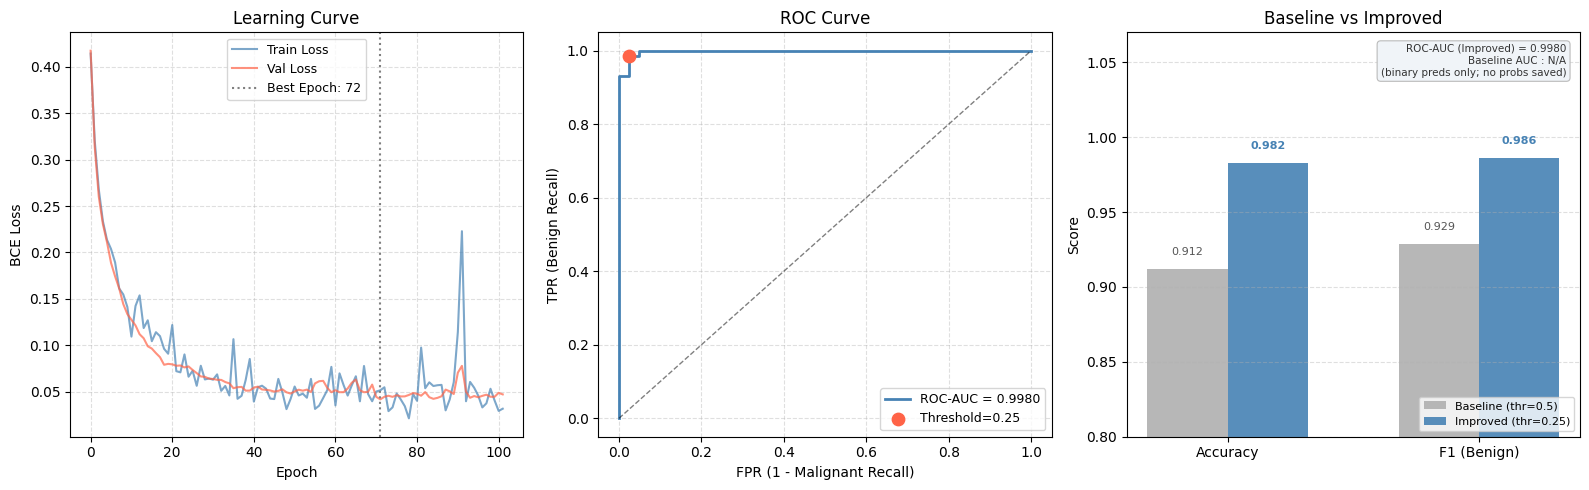

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (1) Learning Curve ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(train_losses, label="Train Loss", color="steelblue", alpha=0.7)
ax.plot(val_losses,   label="Val Loss",   color="tomato",    alpha=0.7)
ax.axvline(best_epoch - 1, color="gray", linestyle=":",
           label=f"Best Epoch: {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Learning Curve")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

# ── (2) ROC Curve ─────────────────────────────────────────────────────────────
ax = axes[1]
fpr_c, tpr_c, _ = roc_curve(y_test, probs_05)
auc_val = roc_auc_score(y_test, probs_05)
ax.plot(fpr_c, tpr_c, color="steelblue", lw=2,
        label=f"ROC-AUC = {auc_val:.4f}")
ax.plot([0,1], [0,1], "k--", lw=1, alpha=0.5)
_, preds_v = get_predictions(model, x_test_t, threshold=best_thr)
fpr_pt = 1 - recall_score(y_test, preds_v, pos_label=0)
tpr_pt =     recall_score(y_test, preds_v, pos_label=1)
ax.scatter([fpr_pt], [tpr_pt], color="tomato", s=80, zorder=5,
           label=f"Threshold={best_thr:.2f}")
ax.set_xlabel("FPR (1 - Malignant Recall)")
ax.set_ylabel("TPR (Benign Recall)")
ax.set_title("ROC Curve")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

# ── (3) Baseline vs Improved ──────────────────────────────────────────────────
# Baseline AUC is NOT computable:
#   Original notebook saved only binary predictions after .round(),
#   discarding probability scores. roc_auc_score requires raw probabilities.
# → Bar chart: Accuracy and F1 only (both available for baseline).
# → AUC: displayed as a text annotation (improved model only).
ax = axes[2]

comp_labels = ["Accuracy", "F1 (Benign)"]
comp_base   = [0.9123, 0.9286]
comp_impr   = [metrics_opt["acc"], metrics_opt["f1"]]

x_pos = np.arange(len(comp_labels))
w = 0.32
bars_b = ax.bar(x_pos - w/2, comp_base, w,
                label="Baseline (thr=0.5)", color="#b0b0b0", alpha=0.9)
bars_i = ax.bar(x_pos + w/2, comp_impr, w,
                label=f"Improved (thr={best_thr:.2f})", color="steelblue", alpha=0.9)

# Value labels: use bar object coordinates directly to avoid manual index math
OFFSET = 0.008
for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + OFFSET,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8, color="#555")
for bar in bars_i:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + OFFSET,
            f"{h:.3f}", ha="center", va="bottom", fontsize=8,
            color="steelblue", fontweight="bold")

ax.set_ylim(0.80, 1.07)
ax.set_xticks(x_pos)
ax.set_xticklabels(comp_labels)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Improved")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.annotate(
    f"ROC-AUC (Improved) = {metrics_opt['auc']:.4f}\n"
    f"Baseline AUC : N/A\n"
    f"(binary preds only; no probs saved)",
    xy=(0.97, 0.97), xycoords="axes fraction",
    ha="right", va="top", fontsize=7.5, color="#333",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#f0f4f8",
              edgecolor="#bbb", linewidth=0.8)
)

plt.tight_layout()
plt.show()

## Train vs Val Loss — Learning Curve 해석

---

### 1. 두 선의 간격 (Gap) → 과적합 제어 여부

* **이론적 기대:**
과적합이 없다면 Train Loss와 Val Loss가 비슷한 수준에서 수렴한다.
과적합이 발생하면 Train Loss는 하락하는데 Val Loss는 오히려 상승하여 간격이 벌어진다.

* **실제 관측: 두 선의 간격이 매우 좁음 → 과적합 제어 성공** : `StandardScaler` + `BatchNorm` + `Dropout(0.3)` + `Weight Decay(1e-4)`의 복합 정규화가
모델이 Train 세트만 외우는 현상을 효과적으로 억제했다.

<br>

---

### 2. 선의 매끄러움 → 학습 안정화 여부

**이론적 기대:**
`BatchNorm`은 층별 입력 분포를 정규화하여 두 커브 모두 매끄럽게 수렴할 것으로 예상된다.

**실제 관측 (예측과 불일치): Train Loss는 지그재그, Val Loss는 매우 매끄러움**

<br>

이 비대칭 패턴은 두 데이터셋의 크기 차이에서 비롯된다.

- **Train Loss (지그재그):** 에포크당 배치 수 ≈ 12개(`n_train≈365 / batch=32`).
  각 배치는 무작위 샘플 32개로 구성되므로 배치마다 손실값이 다르게 계산된다.
  에포크 단위 Train Loss = 배치별 손실의 평균이지만,
  배치 수가 적어 미니배치 노이즈(Mini-batch Noise)가 충분히 상쇄되지 않는다.

- **Val Loss (매끄러움):** `n_val≈91`의 **전체 샘플을 한 번에** 계산한다(`shuffle=False`).
  샘플 수가 클수록 노이즈가 평균화되어 커브가 안정적으로 나타난다.
  즉 Val Loss의 매끄러움은 배치 노이즈가 없는 full-batch 방식의 결과다.

>* **결론:** 지그재그는 `BatchNorm` 실패가 아니라, **소규모 데이터에서 미니배치 노이즈가
> 에포크 평균으로 충분히 상쇄되지 않는** 정상적인 현상이다.
> 배치 크기를 64로 늘리면 노이즈가 감소하지만, 에포크당 배치가 5~6개로 줄어
> 기울기 추정의 다양성이 낮아지는 트레이드오프가 발생한다.

<br>

---

### 3. Val Loss의 반등 지점 → Early Stopping 적정성

**이론적 기대:**
Val Loss가 최솟값에 도달한 후 반등하는 지점이 Early Stopping의 이상적인 중단 시점이다.

**실제 관측:**
- Train Loss: 전반적으로 수렴하나, 에포크 80·90 근방에서 일시적 상승(spike) 발생
- Val Loss: 단조롭게 수렴하며 뚜렷한 U자형 반등 없음

>* **Train Loss Spike의 원인:**
무작위 배치 구성상 특정 에포크에서 어려운 샘플이 같은 배치에 몰릴 수 있다.
`shuffle=True`로 인해 에포크마다 배치 구성이 달라지며, 이 변동성이 spike로 나타난다.
이는 과적합의 신호가 아니라 미니배치 샘플링의 확률적 변동이다.

>* **Val Loss 무반등의 해석:**
Val Loss가 최솟값으로 수렴 중이라면 Early Stopping의 `patience=30` 설정이 적절하게
작동하고 있음을 의미한다. 단, Val Loss가 plateau(수평 정체)에 진입했다면
추가 학습은 실질적 개선 없이 계산 비용만 증가한다.
`best_epoch`가 전체 에포크의 70% 이전에 발동되었다면 Early Stopping이 유효하게 작동한 것이다.

---
## 10. 최종 요약 및 한계

### 개선 내용 요약

In [17]:
print("=" * 60)
print("  이진분류 개선 실험 최종 요약")
print("=" * 60)
print(f"  SEED: {SEED}  |  Device: {device}  |  Batch: {BATCH_SIZE}")
print(f"  Best Epoch: {best_epoch} / {NUM_EPOCHS}  (Early Stop patience={PATIENCE})")
print(f"  Best Threshold: {best_thr:.2f}")
print("-" * 60)
print(f"  {'지표':<25} {'기존 (Acc=0.91)':>15} {'개선':>15}")
print("-" * 60)
print(f"  {'Accuracy':<25} {'0.9123':>15} {metrics_opt['acc']:>15.4f}")
print(f"  {'F1 (Benign, pos=1)':<25} {'0.9286':>15} {metrics_opt['f1']:>15.4f}")
print(f"  {'ROC-AUC':<25} {'미측정':>15} {metrics_opt['auc']:>15.4f}")
print(f"  {'Malignant Recall':<25} {'미측정':>15} {metrics_opt['recall_mal']:>15.4f}")
print("=" * 60)
print()
print("  [적용한 개선 기법]")
print("  1. StandardScaler           — 피처 스케일 정규화")
print("  2. BatchNorm + Dropout(0.3) — 수렴 안정화 + 정규화")
print("  3. BCEWithLogitsLoss        — Sigmoid 수치 안정성")
print("  4. pos_weight               — 클래스 불균형 보정")
print("  5. Early Stopping           — 최적 에포크 자동 포착")
print("  6. 평가 지표 강화           — Confusion Matrix · AUC · Recall")
print("  7. 임계값 최적화            — Malignant Recall 목표 달성")

  이진분류 개선 실험 최종 요약
  SEED: 42  |  Device: cuda  |  Batch: 32
  Best Epoch: 72 / 300  (Early Stop patience=30)
  Best Threshold: 0.25
------------------------------------------------------------
  지표                          기존 (Acc=0.91)              개선
------------------------------------------------------------
  Accuracy                           0.9123          0.9825
  F1 (Benign, pos=1)                 0.9286          0.9861
  ROC-AUC                               미측정          0.9980
  Malignant Recall                      미측정          0.9762

  [적용한 개선 기법]
  1. StandardScaler           — 피처 스케일 정규화
  2. BatchNorm + Dropout(0.3) — 수렴 안정화 + 정규화
  3. BCEWithLogitsLoss        — Sigmoid 수치 안정성
  4. pos_weight               — 클래스 불균형 보정
  5. Early Stopping           — 최적 에포크 자동 포착
  6. 평가 지표 강화           — Confusion Matrix · AUC · Recall
  7. 임계값 최적화            — Malignant Recall 목표 달성


---
## 가정 · 한계 · 다음 단계

### 가정
- `stratify=y` 분할로 클래스 비율을 각 세트에서 동일하게 유지했다.
- `pos_weight`는 Train 세트 기준으로 계산했다 (전체 데이터 기준과 거의 동일).
- 임계값 목표(Malignant Recall ≥ 0.95)는 예시이며, 실제 임상 프로토콜에 따라 변경해야 한다.

<br>

---

### 한계
- **K-Fold CV 미적용:** n=569의 단일 분할로는 성능 추정의 분산이 크다.
- **하이퍼파라미터 탐색 없음:** `dropout_p`, `weight_decay`, `patience`는 수동 설정.
- **피처 선택 미수행:** 30개 피처 중 일부는 상관이 높아 제거 시 일반화 성능 향상 가능.

<br>

---

### 다음 단계

| 항목 | 방법 |
|------|------|
| 일반화 성능 검증 | K-Fold CV (k=5) |
| 하이퍼파라미터 자동 탐색 | Optuna |
| 피처 중요도 분석 | SHAP (SHapley Additive exPlanations) |
| 모델 비교 | XGBoost, SVM, RandomForest vs MLP |
| 불균형 추가 처리 | SMOTE (오버샘플링) 비교 실험 |